In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

In [3]:
print("\n2️⃣ TensorFlow:")
try:
    import tensorflow as tf
    print(f"   ✅ Version: {tf.__version__}")
    
    # Vérifier GPU
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        print(f"   ✅ GPU détecté: {len(gpus)} GPU(s)")
        for gpu in gpus:
            print(f"      - {gpu}")
    else:
        print("   ⚠️ Aucun GPU (utilise CPU)")
        
except ImportError as e:
    print(f"   ❌ TensorFlow non installé: {e}")
    print("\n   💡 SOLUTION:")
    print("      pip install tensorflow")
    
except Exception as e:
    print(f"   ❌ ERREUR: {e}")




2️⃣ TensorFlow:
   ✅ Version: 2.10.0
   ⚠️ Aucun GPU (utilise CPU)


In [4]:
from tensorflow.keras.models import load_model
from PIL import Image
import numpy as np
import json
import matplotlib.pyplot as plt
import os
import random

print("✅ Imports réussis!")


✅ Imports réussis!


In [5]:
print("🔄 Chargement du modèle...")

# Charger le modèle
model = load_model('best_model.h5')
print("✅ Modèle chargé!")

# Charger les noms de classes
with open('class_names.json', 'r') as f:
    class_names = json.load(f)
print(f"✅ {len(class_names)} classes chargées")

# Path du dataset
BASE_PATH = "C:/Users/MSI/Documents/PlantDiseaseProject/data/PlantVillage"


🔄 Chargement du modèle...
✅ Modèle chargé!
✅ 15 classes chargées


In [6]:
# ────────────────────────────────────────────────────
# CELLULE 3: Fonction de prédiction
# ────────────────────────────────────────────────────
def predict_disease(image_path, model, class_names):
    """
    Prédit la maladie d'une plante à partir d'une image
    """
    # Charger et prétraiter l'image
    img = Image.open(image_path)
    img = img.convert('RGB')
    img = img.resize((64, 64))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # Ajouter dimension batch
    
    # Prédiction
    predictions = model.predict(img_array, verbose=0)
    predicted_class_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class_idx]
    predicted_class = class_names[predicted_class_idx]
    
    # Afficher les 3 meilleures prédictions
    top_3_idx = np.argsort(predictions[0])[-3:][::-1]
    
    print(f"\n🔍 Résultats de la prédiction:")
    print(f"   Classe prédite: {predicted_class}")
    print(f"   Confiance: {confidence*100:.2f}%")
    print(f"\n📊 Top 3 des prédictions:")
    for i, idx in enumerate(top_3_idx, 1):
        print(f"   {i}. {class_names[idx]}: {predictions[0][idx]*100:.2f}%")
    
    return predicted_class, confidence
print("✅ Fonction de prédiction prête!")

✅ Fonction de prédiction prête!


In [7]:
# ────────────────────────────────────────────────────
# CELLULE 4: Fonction pour récupérer une image aléatoire
# ────────────────────────────────────────────────────
def get_random_image(base_path):
    """Récupère une image aléatoire du dataset"""
    folders = [f for f in os.listdir(base_path) 
              if os.path.isdir(os.path.join(base_path, f))]
    random_folder = random.choice(folders)
    folder_path = os.path.join(base_path, random_folder)
    images = [f for f in os.listdir(folder_path) 
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random_image = random.choice(images)
    return os.path.join(folder_path, random_image), random_folder

print("✅ Fonction get_random_image prête!")


✅ Fonction get_random_image prête!


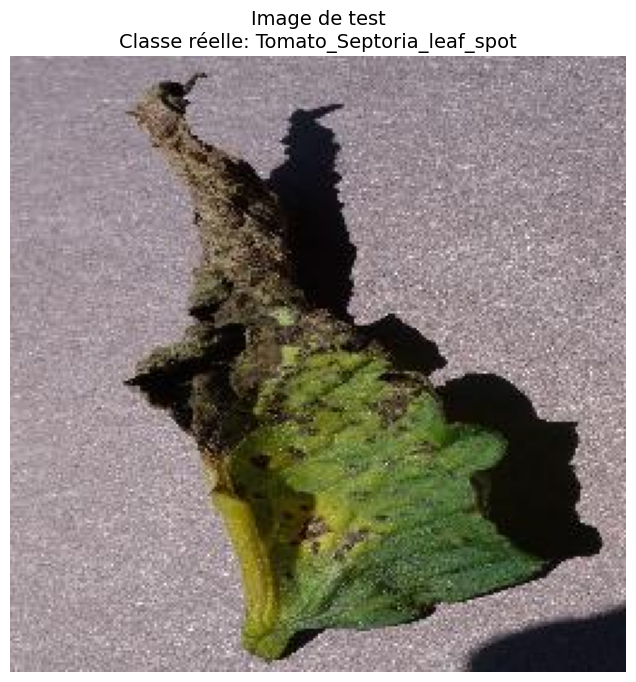


🔍 Résultats de la prédiction:
   Classe prédite: Tomato_Septoria_leaf_spot
   Confiance: 98.50%

📊 Top 3 des prédictions:
   1. Tomato_Septoria_leaf_spot: 98.50%
   2. Pepper__bell___Bacterial_spot: 1.11%
   3. Tomato_Early_blight: 0.25%

✅ PRÉDICTION CORRECTE!


In [8]:
# ────────────────────────────────────────────────────
# CELLULE 5: Tester sur UNE image aléatoire
# ────────────────────────────────────────────────────

# Tester sur une image
test_image_path, true_class = get_random_image(BASE_PATH)

# Afficher l'image
img = Image.open(test_image_path)
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.title(f"Image de test\nClasse réelle: {true_class}", fontsize=14)
plt.axis('off')
plt.show()

# Faire la prédiction
predicted_class, confidence = predict_disease(test_image_path, model, class_names)

# Vérifier si c'est correct
if predicted_class == true_class:
    print("\n✅ PRÉDICTION CORRECTE!")
else:
    print(f"\n❌ ERREUR: Prédit {predicted_class}, mais c'est {true_class}")


In [9]:
# ────────────────────────────────────────────────────
# CELLULE 6: Tester sur PLUSIEURS images (10 images)
# ────────────────────────────────────────────────────

def test_multiple_images(n=10):
    """Teste le modèle sur N images aléatoires"""
    correct = 0
    
    for i in range(n):
        # Récupérer une image aléatoire
        test_image_path, true_class = get_random_image(BASE_PATH)
        
        # Prédire sans afficher l'image
        img = Image.open(test_image_path)
        img = img.convert('RGB')
        img = img.resize((128, 128))
        img_array = np.array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        
        predictions = model.predict(img_array, verbose=0)
        predicted_class_idx = np.argmax(predictions[0])
        predicted_class = class_names[predicted_class_idx]
        confidence = predictions[0][predicted_class_idx]
        
        # Vérifier
        is_correct = predicted_class == true_class
        if is_correct:
            correct += 1
        
        status = "✅" if is_correct else "❌"
        print(f"{status} Test {i+1}/{n}: Vrai={true_class}, Prédit={predicted_class} ({confidence*100:.1f}%)")
    
    print(f"\n{'='*60}")
    print(f"📊 RÉSULTAT FINAL: {correct}/{n} = {correct/n*100:.1f}% de précision")
    print(f"{'='*60}")

# Lancer le test sur 10 images
test_multiple_images(10)

✅ Test 1/10: Vrai=Potato___Late_blight, Prédit=Potato___Late_blight (95.3%)
✅ Test 2/10: Vrai=Tomato_Late_blight, Prédit=Tomato_Late_blight (99.8%)
✅ Test 3/10: Vrai=Tomato__Tomato_mosaic_virus, Prédit=Tomato__Tomato_mosaic_virus (99.8%)
✅ Test 4/10: Vrai=Tomato_Septoria_leaf_spot, Prédit=Tomato_Septoria_leaf_spot (99.9%)
✅ Test 5/10: Vrai=Pepper__bell___healthy, Prédit=Pepper__bell___healthy (99.5%)
✅ Test 6/10: Vrai=Tomato_healthy, Prédit=Tomato_healthy (91.2%)
✅ Test 7/10: Vrai=Pepper__bell___Bacterial_spot, Prédit=Pepper__bell___Bacterial_spot (95.3%)
❌ Test 8/10: Vrai=Tomato_Bacterial_spot, Prédit=Tomato_Septoria_leaf_spot (84.5%)
❌ Test 9/10: Vrai=Tomato_Bacterial_spot, Prédit=Tomato_Septoria_leaf_spot (77.4%)
❌ Test 10/10: Vrai=Tomato__Target_Spot, Prédit=Tomato_Early_blight (59.3%)

📊 RÉSULTAT FINAL: 7/10 = 70.0% de précision


In [10]:
# ────────────────────────────────────────────────────
# CELLULE 7: Tester sur une image SPÉCIFIQUE 
# ────────────────────────────────────────────────────

# Si vous voulez tester une image spécifique, changez le chemin ici:
specific_image = "C:/Users/MSI/Documents/PlantDiseaseProject/data/PlantVillage/Tomato__healthy/image.JPG"

# Vérifier que le fichier existe
if os.path.exists(specific_image):
    img = Image.open(specific_image)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title("Image spécifique à tester")
    plt.axis('off')
    plt.show()
    
    predicted_class, confidence = predict_disease(specific_image, model, class_names)
else:
    print(f"⚠️ Fichier introuvable: {specific_image}")
    print("💡 Changez le chemin dans la cellule ci-dessus")

⚠️ Fichier introuvable: C:/Users/MSI/Documents/PlantDiseaseProject/data/PlantVillage/Tomato__healthy/image.JPG
💡 Changez le chemin dans la cellule ci-dessus


In [11]:
# ────────────────────────────────────────────────────
# CELLULE 8: Analyse par classe
# ────────────────────────────────────────────────────

def analyze_per_class(samples_per_class=5):
    """Analyse la précision pour chaque classe"""
    print("📊 Analyse de précision par classe:\n")
    
    results = {}
    
    for class_name in class_names:
        folder_path = os.path.join(BASE_PATH, class_name)
        
        if not os.path.exists(folder_path):
            continue
        
        images = [f for f in os.listdir(folder_path) 
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        if len(images) < samples_per_class:
            continue
        
        # Tester N images de cette classe
        sample_images = random.sample(images, samples_per_class)
        correct = 0
        
        for img_name in sample_images:
            img_path = os.path.join(folder_path, img_name)
            
            img = Image.open(img_path).convert('RGB').resize((128, 128))
            img_array = np.expand_dims(np.array(img)/255.0, 0)
            predictions = model.predict(img_array, verbose=0)
            predicted_class = class_names[np.argmax(predictions[0])]
            
            if predicted_class == class_name:
                correct += 1
        
        accuracy = correct / samples_per_class * 100
        results[class_name] = accuracy
        
        status = "✅" if accuracy >= 80 else "⚠️" if accuracy >= 60 else "❌"
        print(f"{status} {class_name}: {correct}/{samples_per_class} = {accuracy:.1f}%")
    
    # Moyenne
    avg_accuracy = sum(results.values()) / len(results)
    print(f"\n{'='*60}")
    print(f"📈 Précision moyenne: {avg_accuracy:.1f}%")
    print(f"{'='*60}")

# Analyser 5 images par classe
analyze_per_class(5)

📊 Analyse de précision par classe:

✅ Pepper__bell___Bacterial_spot: 5/5 = 100.0%
✅ Pepper__bell___healthy: 5/5 = 100.0%
⚠️ Potato___Early_blight: 3/5 = 60.0%
✅ Potato___Late_blight: 4/5 = 80.0%
⚠️ Potato___healthy: 3/5 = 60.0%
✅ Tomato_Bacterial_spot: 5/5 = 100.0%
✅ Tomato_Early_blight: 5/5 = 100.0%
✅ Tomato_Late_blight: 5/5 = 100.0%
✅ Tomato_Leaf_Mold: 5/5 = 100.0%
✅ Tomato_Septoria_leaf_spot: 4/5 = 80.0%
⚠️ Tomato_Spider_mites_Two_spotted_spider_mite: 3/5 = 60.0%
⚠️ Tomato__Target_Spot: 3/5 = 60.0%
❌ Tomato__Tomato_YellowLeaf__Curl_Virus: 2/5 = 40.0%
✅ Tomato__Tomato_mosaic_virus: 5/5 = 100.0%
✅ Tomato_healthy: 5/5 = 100.0%

📈 Précision moyenne: 82.7%


In [12]:
"""
INTERFACE GRADIO MODERNE ET STYLÉE
Design professionnel avec couleurs et mise en page améliorée
"""
import gradio as gr
from tensorflow.keras.models import load_model
from PIL import Image
import numpy as np
import json

# Charger le modèle
print("🔄 Chargement du modèle...")
model = load_model('best_model.h5')
with open('class_names.json', 'r') as f:
    class_names = json.load(f)
print("✅ Modèle chargé!\n")

def predict(image):
    """Fonction de prédiction pour Gradio"""
    if image is None:
        return {"⚠️ Erreur": 1.0}
    
    try:
        # Prétraiter
        img = Image.fromarray(image.astype('uint8'), 'RGB')
        img = img.resize((64, 64))
        img_array = np.array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        
        # Prédire
        predictions = model.predict(img_array, verbose=0)
        
        # Top 5 avec émojis
        top_5_idx = np.argsort(predictions[0])[-5:][::-1]
        results = {}
        
        for idx in top_5_idx:
            class_name = class_names[idx]
            confidence = float(predictions[0][idx])
            
            # Ajouter un émoji selon la maladie
            if "healthy" in class_name.lower():
                emoji = "✅"
            elif "blight" in class_name.lower():
                emoji = "🍂"
            elif "spot" in class_name.lower():
                emoji = "🔴"
            elif "mold" in class_name.lower():
                emoji = "🟢"
            elif "virus" in class_name.lower():
                emoji = "🦠"
            else:
                emoji = "🌿"
            
            results[f"{emoji} {class_name}"] = confidence
        
        return results
    
    except Exception as e:
        return {"❌ Erreur": str(e)}

# ========================================
# INTERFACE AVEC DESIGN PERSONNALISÉ
# ========================================

# CSS personnalisé pour un beau design
custom_css = """
#component-0 {
    background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
    padding: 20px;
    border-radius: 10px;
}

.gradio-container {
    font-family: 'Arial', sans-serif;
    max-width: 1200px;
    margin: auto;
}

#title {
    text-align: center;
    color: white;
    font-size: 2.5em;
    font-weight: bold;
    margin-bottom: 10px;
    text-shadow: 2px 2px 4px rgba(0,0,0,0.3);
}

#description {
    text-align: center;
    color: #f0f0f0;
    font-size: 1.1em;
    margin-bottom: 20px;
}

.input-image {
    border: 3px dashed #667eea !important;
    border-radius: 15px !important;
    padding: 20px !important;
    background: linear-gradient(to bottom, #f0f4ff, #ffffff) !important;
}

.output-label {
    background: linear-gradient(to right, #f093fb 0%, #f5576c 100%) !important;
    border-radius: 10px !important;
    padding: 15px !important;
}

footer {
    display: none !important;
}

button {
    background: linear-gradient(135deg, #667eea 0%, #764ba2 100%) !important;
    border: none !important;
    color: white !important;
    font-weight: bold !important;
    padding: 12px 30px !important;
    border-radius: 25px !important;
    font-size: 1.1em !important;
    transition: transform 0.2s !important;
}

button:hover {
    transform: scale(1.05) !important;
    box-shadow: 0 5px 15px rgba(102, 126, 234, 0.4) !important;
}
"""

# Créer l'interface avec Blocks pour plus de contrôle
with gr.Blocks(css=custom_css, title="🌱 Plant Disease Detector") as demo:
    
    # En-tête
    gr.HTML("""
        <div style='text-align: center; background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); 
                    padding: 30px; border-radius: 15px; margin-bottom: 20px;'>
            <h1 style='color: white; font-size: 3em; margin: 0; text-shadow: 2px 2px 4px rgba(0,0,0,0.3);'>
                🌱 Détection de Maladies des Plantes
            </h1>
            <p style='color: #f0f0f0; font-size: 1.2em; margin-top: 10px;'>
                Intelligence Artificielle pour l'Agriculture Intelligente
            </p>
        </div>
    """)
    
    # Instructions
    gr.Markdown("""
    ### 📋 Comment utiliser?
    1. **Téléchargez** une image de feuille de plante
    2. **Cliquez** sur "Analyser"
    3. **Recevez** instantanément le diagnostic!
    
    **Plantes supportées:** 🍅 Tomate | 🥔 Pomme de terre | 🌶️ Poivron
    """)
    
    # Ligne avec 2 colonnes
    with gr.Row():
        # Colonne gauche: Input
        with gr.Column(scale=1):
            gr.Markdown("### 📸 Votre Image")
            image_input = gr.Image(
                label="Glissez votre image ici",
                type="numpy",
                elem_classes="input-image"
            )
            
            submit_btn = gr.Button("🔍 Analyser la Plante", variant="primary", size="lg")
            
            gr.Markdown("""
            **💡 Conseils:**
            - Utilisez une image claire
            - Centrez la feuille
            - Lumière naturelle préférable
            """)
        
        # Colonne droite: Output
        with gr.Column(scale=1):
            gr.Markdown("### 🎯 Résultats du Diagnostic")
            label_output = gr.Label(
                label="Prédictions",
                num_top_classes=5,
                elem_classes="output-label"
            )
            
            gr.Markdown("""
            **📊 Interprétation:**
            - ✅ Sain: Aucun traitement nécessaire
            - 🍂 Blight: Maladie fongique
            - 🔴 Spot: Infection bactérienne
            - 🦠 Virus: Infection virale
            """)
    
    # Pied de page avec stats
    gr.HTML("""
        <div style='background: linear-gradient(to right, #f093fb 0%, #f5576c 100%); 
                    padding: 20px; border-radius: 10px; text-align: center; margin-top: 30px;'>
            <h3 style='color: white; margin: 0;'>📈 Statistiques du Modèle</h3>
            <div style='display: flex; justify-content: space-around; margin-top: 15px;'>
                <div style='color: white;'>
                    <div style='font-size: 2em; font-weight: bold;'>90.26%</div>
                    <div>Précision</div>
                </div>
                <div style='color: white;'>
                    <div style='font-size: 2em; font-weight: bold;'>16</div>
                    <div>Classes</div>
                </div>
                <div style='color: white;'>
                    <div style='font-size: 2em; font-weight: bold;'>20K+</div>
                    <div>Images</div>
                </div>
            </div>
        </div>
    """)
    
    # Footer
    gr.Markdown("""
    ---
    💻 Développé avec TensorFlow & Gradio | 🧠 CNN Deep Learning | 📊 Projet Big Data
    """, elem_id="footer")
    
    # Event handler
    submit_btn.click(
        fn=predict,
        inputs=image_input,
        outputs=label_output
    )
    
    # Auto-submit quand image uploadée
    image_input.change(
        fn=predict,
        inputs=image_input,
        outputs=label_output
    )

# Lancer l'interface
print("🚀 Lancement de l'interface Gradio stylée...")
demo.launch(
    share=True,
    debug=False,
    inbrowser=True,
    server_name="0.0.0.0",  # Accessible depuis le réseau local
    favicon_path=None
)

print("""
✅ Interface lancée avec succès!
🌐 Lien local: http://127.0.0.1:7860
🔗 Lien public: Voir dans le terminal ci-dessus (valable 72h)
""")

🔄 Chargement du modèle...
✅ Modèle chargé!

🚀 Lancement de l'interface Gradio stylée...
Running on local URL:  http://0.0.0.0:7860
IMPORTANT: You are using gradio version 3.50.0, however version 4.44.1 is available, please upgrade.
--------

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.



✅ Interface lancée avec succès!
🌐 Lien local: http://127.0.0.1:7860
🔗 Lien public: Voir dans le terminal ci-dessus (valable 72h)

